# **Masked prediction analysis: convolution layers only**

## Navigation

- [**Basic imports and initialization**](#Basic-imports-and-initialization)
- [**1. Alexnet**](#1.-Alexnet)
- [**2. ResNet18**](#2.-ResNet18)

## Basic imports and initialization

$\qquad$ [[Back to top]](#Navigation) $\qquad$ [[Next part $\to$]](#1.-Alexnet)

- [Setting up templates, limiting the hardware resources, importing packages](#Setting-up-templates,-limiting-the-hardware-resources,-importing-packages)
- [Initializing common variables](#Initializing-common-variables)
- [Configuring experiments and generating corresponding sh-files](#Configuring-experiments-and-generating-corresponding-sh-files)

### Setting up templates, limiting the hardware resources, importing packages

$\quad$[[Back to section]](#Basic-imports-and-initialization)$\quad$[[Next subsect.$\to$]](#Initializing-common-variables)

In [1]:
notebook_directory_offset = '../'
sh_file_type = 'base'
libstdcpp_path = ''

In the case of problems with loading ```libstc++.so.6```, please provide the path to the library. In any other case, just ignore the following block.

In [2]:
import ctypes

libstdcpp_path = '/mnt/bulky/pkharyuk/apd/envs/activation_sense/lib/libstdc++.so.6'
try:
    _stdcxx_lib = ctypes.cdll.LoadLibrary(libstdcpp_path)
except:
    pass

To provide easy access to modules stored in the ```../src/``` directory, we use the following workaround:

In [2]:
import os
import sys
sys.path.append(
    os.path.join(notebook_directory_offset, '../src/')
)

Next, we limit the hardware usage by setting the configuration dictionaries, maximum number of threads:

In [3]:
# set limitations on hardware
# fill on the template's config
import hardware_setup

mkl_num_threads = 4
hardware_setup.mkl_set_num_threads(num_threads=mkl_num_threads)

available_gpu_idxs = [0, 2, 3]
max_n_cuda = len(available_gpu_idxs)

[mkl]: set up num_threads=4/4


Then we import all necessary packages:

In [4]:
import copy

import numpy as np

import sensitivity_analysis.augmentation_setting
import sensitivity_analysis.visualize
import sensitivity_analysis.preprocess_visualize

import preparation.single_unit
import preparation.visualize

import exp_assistance

import prediction.compute
import prediction.compute_separated
import prediction.crosscorr
import prediction.hca

import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import display

### Initializing common variables

[[$\leftarrow$Prev.subsect.]](#Setting-up-templates,-limiting-the-hardware-resources,-importing-packages)$\quad$[[Back to section]](#Basic-imports-and-initialization)$\quad$[[Next subsect.$\to$]](#Configuring-experiments-and-generating-corresponding-sh-files)

In [12]:
dataset_name = 'places365'
data_dirname = f'../data/{dataset_name}'

sensitivity_values_dirname = '../results/'
model_dirname = '../torch-models/'
scripts_path = '../scripts/'
exp_relative_path = '../experiments/'

values_fnm_base = f'{dataset_name}_values'
output_filename_suffix = 'pred_NOFCL'

results_dirname_path = '../results/'

desired_image_height = 224
desired_image_width = 224

dataset_part = 'valid'

sensitivity_values_name_list = (
    'shpv', 'si', 'siT'
)
no_aug_key = 'original'
y_true_key = 'true_labels'

alphas = (0., 0.5, 1.5)
percentiles = (0.5, 0.6, 0.7, 0.8, 0.9)
inverts = (0, 1)

augmentation_set_numbers_list = (1, 2)

linkage_hca = 'average'

cmap_cormat = 'Reds_r'
cmap_hca = 'twilight_shifted'
label_cmap_hca = 'brg_r'
max_d_label_hca = 0.025
label_background_color_hca = '#0000001A'
label_fontsize_hca = 8

figsizes_cormat = ((5*3+1, 3), (6*3+1, 4))
figsizes_hca = ((3*4+1, 8), (3*4+1, 12))

sensitivity_value_name_list = (
    'shpv',
    'si',
    'siT',
)

In [6]:
basic_config_dict = {
    'recompute_predictions': 1,
    'batch_size_computing': 100,
    'samples_per_class_train': 3068,
    'samples_per_class_valid': 100,
    'augmentation_set_number': 3, # 1+2
    'dataset_part': dataset_part,
    'Nsamples': 100*365,
    'Ninner_samples': 3,
    #'os_environment_config',
    'mkl_num_threads': mkl_num_threads,
    'data_dirname': data_dirname,
    'dataset': dataset_name,
    'model_dirname': model_dirname,
    'desired_image_height': desired_image_height,
    'desired_image_width': desired_image_width,
    'use_permutation_variable': 1,
    'use_class_variable': 1,
    'use_partition_variable': 1,
    'alphas': f'"{alphas}"', #exp_assistance.convert_list2argstr(alphas),
    'percentiles': f'"{percentiles}"', #exp_assistance.convert_list2argstr(percentiles),
    'top_n_predictions': 5,
    'sensitivity_values_dirname': sensitivity_values_dirname,
    'values_fnm_base': values_fnm_base,
    'output_filename_suffix': output_filename_suffix,
}
if len(libstdcpp_path) > 0:
    basic_config_dict['libstdcpp_path'] = libstdcpp_path

### Configuring experiments and generating corresponding sh-files

[[$\leftarrow$Prev.subsect.]](#Initializing-common-variables)$\quad$[[Back to section]](#Basic-imports-and-initialization)$\quad$

- [Alexnet](#Alexnet)
- [ResNet18](#ResNet18)


#### Alexnet

[[Back to section]](#Configuring-experiments-and-generating-corresponding-sh-files)

In [7]:
# alexnet
alexnet_network_name = 'alexnet'
alexnet_model_filename = 'alexnet_places365.pth.tar'

alexnet_network_modules = [
    'features.2', # Conv2d + ReLU + MaxPool2d
    'features.5', # ... + Conv2d + ReLU + MaxPool2d
    'features.7', # ... + Conv2d + ReLU
    'features.9', # ... + Conv2d + ReLU
    #'features.12', # ... + Conv2d + ReLU + MaxPool2d
    'avgpool', # ... + Conv2d + ReLU + MaxPool2d + AdaptiveAvgPool
]
alexnet_network_modules = exp_assistance.convert_list2argstr(
    alexnet_network_modules
)
alexnet_classification_layer_name = 'classifier.6'

In [8]:
config_dict_alexnet = copy.deepcopy(basic_config_dict)

config_dict_alexnet['device'] = 'cuda' # manually select visible device in the result
config_dict_alexnet['network_name'] = alexnet_network_name
config_dict_alexnet['network_modules'] = alexnet_network_modules
config_dict_alexnet['classification_layer_name'] = alexnet_classification_layer_name
config_dict_alexnet['model_filename'] = alexnet_model_filename

In [8]:
config_dict_alexnet_shpv = copy.deepcopy(config_dict_alexnet)

config_dict_alexnet_shpv['sensitivity_values_name'] = 'shpv'
config_dict_alexnet_shpv['subset_random_state_train'] = 777
config_dict_alexnet_shpv['subset_random_state_valid'] = 111
config_dict_alexnet_shpv['torch_seed'] = 390
config_dict_alexnet_shpv['numpy_seed'] = 231
config_dict_alexnet_shpv['class_sampler_seed'] = 89
config_dict_alexnet_shpv['class_selector_seed'] = 11976
config_dict_alexnet_shpv['augpar_sampler_seeds'] = 34

In [8]:
config_dict_alexnet_si = copy.deepcopy(config_dict_alexnet)

config_dict_alexnet_si['sensitivity_values_name'] = 'si'
config_dict_alexnet_si['subset_random_state_train'] = 999
config_dict_alexnet_si['subset_random_state_valid'] = 981
config_dict_alexnet_si['torch_seed'] = 708
config_dict_alexnet_si['numpy_seed'] = 152
config_dict_alexnet_si['class_sampler_seed'] = 2849
config_dict_alexnet_si['class_selector_seed'] = 57
config_dict_alexnet_si['augpar_sampler_seeds'] = 17

In [8]:
config_dict_alexnet_siT = copy.deepcopy(config_dict_alexnet)

config_dict_alexnet_siT['sensitivity_values_name'] = 'siT'
config_dict_alexnet_siT['subset_random_state_train'] = 10101
config_dict_alexnet_siT['subset_random_state_valid'] = 989
config_dict_alexnet_siT['torch_seed'] = 331
config_dict_alexnet_siT['numpy_seed'] = 701
config_dict_alexnet_siT['class_sampler_seed'] = 22
config_dict_alexnet_siT['class_selector_seed'] = 900
config_dict_alexnet_siT['augpar_sampler_seeds'] = 732

In [9]:
####################################################################################
script_filename_base = f'script_exp3_{alexnet_network_name}_{dataset_name}_{output_filename_suffix}'
exp_filename = '3a_masked_prediction.py'
exp_script_path = os.path.join(exp_relative_path, exp_filename)
for current_config_dict in (
    config_dict_alexnet_shpv,
    config_dict_alexnet_si,
    config_dict_alexnet_siT
):
    sensitivity_value_name = current_config_dict['sensitivity_values_name
    current_config_dict['results_dirname_path'] = os.path.join(
        results_dirname_path,
        alexnet_network_name,
        sensitivity_value_name
    )
    if current_config_dict['device'].startswith('cuda'):
        current_config_dict['device'] = current_config_dict['device'].split(':')[0]
        #current_config_dict['device'] += f':{available_gpu_idxs[i%max_n_cuda]}'
    current_script_filename = f'{script_filename_base}_sensval={sensitivity_value_name}.sh'
    current_script_path = os.path.join(
        notebook_directory_offset,
        scripts_path,
        current_script_filename
    )
    exp_assistance.build_sh_exp_files(
        current_config_dict,
        script_path=current_script_path,
        experiment_file_path=exp_script_path,
        notebook_directory_offset=notebook_directory_offset,
        which=sh_file_type,
    );

#### ResNet18

[[Back to section]](#Configuring-experiments-and-generating-corresponding-sh-files)

In [7]:
# resnet18
resnet18_network_name = 'resnet18'
resnet18_model_filename = 'resnet18_places365.pth.tar'

resnet18_network_modules = [
    'maxpool', # conv2d -> BN -> ReLU -> MaxPool2d
    'layer1', # Basic ResNet Block 1
    'layer2', # Basic ResNet Block 2
    'layer3', # Basic ResNet Block 3
    #'avgpool', # Basic ResNet Block 1 -> AvgPool
]
resnet18_network_modules = exp_assistance.convert_list2argstr(
    resnet18_network_modules
)
resnet18_classification_layer_name = 'fc'

In [8]:
config_dict_resnet18 = copy.deepcopy(basic_config_dict)

config_dict_resnet18['device'] = 'cuda'
config_dict_resnet18['network_name'] = resnet18_network_name
config_dict_resnet18['network_modules'] = resnet18_network_modules
config_dict_resnet18['classification_layer_name'] = resnet18_classification_layer_name
config_dict_resnet18['model_filename'] = resnet18_model_filename
config_dict_resnet18['mkl_num_threads'] = 6

In [8]:
config_dict_resnet18_shpv = copy.deepcopy(config_dict_resnet18)

config_dict_resnet18_shpv['sensitivity_values_name'] = 'shpv'
config_dict_resnet18_shpv['subset_random_state_train'] = 432
config_dict_resnet18_shpv['subset_random_state_valid'] = 154
config_dict_resnet18_shpv['torch_seed'] = 906
config_dict_resnet18_shpv['numpy_seed'] = 772
config_dict_resnet18_shpv['class_sampler_seed'] = 322
config_dict_resnet18_shpv['class_selector_seed'] = 1111
config_dict_resnet18_shpv['augpar_sampler_seeds'] = 5454

In [8]:
config_dict_resnet18_si = copy.deepcopy(config_dict_resnet18)

config_dict_resnet18_si['sensitivity_values_name'] = 'si'
config_dict_resnet18_si['subset_random_state_train'] = 4876
config_dict_resnet18_si['subset_random_state_valid'] = 7654
config_dict_resnet18_si['torch_seed'] = 34453
config_dict_resnet18_si['numpy_seed'] = 11232
config_dict_resnet18_si['class_sampler_seed'] = 8887
config_dict_resnet18_si['class_selector_seed'] = 90870
config_dict_resnet18_si['augpar_sampler_seeds'] = 3421

In [8]:
config_dict_resnet18_siT = copy.deepcopy(config_dict_resnet18)

config_dict_resnet18_siT['sensitivity_values_name'] = 'siT'
config_dict_resnet18_siT['subset_random_state_train'] = 54548
config_dict_resnet18_siT['subset_random_state_valid'] = 74454
config_dict_resnet18_siT['torch_seed'] = 432
config_dict_resnet18_siT['numpy_seed'] = 767
config_dict_resnet18_siT['class_sampler_seed'] = 4321
config_dict_resnet18_siT['class_selector_seed'] = 54
config_dict_resnet18_siT['augpar_sampler_seeds'] = 8704

In [21]:
####################################################################################
script_filename_base = f'script_exp3_{resnet18_network_name}_{dataset_name}_{output_filename_suffix}'
exp_filename = '3a_masked_prediction.py'
exp_script_path = os.path.join(exp_relative_path, exp_filename)
for current_config_dict in (
    config_dict_resnet18_shpv,
    config_dict_resnet18_si,
    config_dict_resnet18_siT
):
    sensitivity_value_name = current_config_dict['sensitivity_values_name
    current_config_dict['results_dirname_path'] = os.path.join(
        results_dirname_path,
        resnet18_network_name,
        sensitivity_value_name
    )
    if current_config_dict['device'].startswith('cuda'):
        current_config_dict['device'] = current_config_dict['device'].split(':')[0]
        #current_config_dict['device'] += f':{available_gpu_idxs[i%max_n_cuda]}'
    current_script_filename = f'{script_filename_base}_sensval={sensitivity_value_name}.sh'
    current_script_path = os.path.join(
        notebook_directory_offset, scripts_path, current_script_filename
    )
    exp_assistance.build_sh_exp_files(
        current_config_dict,
        script_path=current_script_path,
        experiment_file_path=exp_script_path,
        notebook_directory_offset=notebook_directory_offset,
        which=sh_file_type,
    );

## 1. Alexnet

[[$\leftarrow$ Prev.part]](#Basic-imports-and-initialization) $\qquad$ [[Back to top]](#Navigation) $\qquad$ [[Next part $\to$]](#2.-ResNet18)


- [1.1 Extract accuracy measurements](#1.1-Extract-accuracy-measurements)
- [1.2 Spearman correlation between original and augmented inputs (both masked)](#1.2-Spearman-correlation-between-original-and-augmented-inputs-(both-masked))
- [1.3 Hierarchical cluster analysis for augmented inputs with masked activations](#1.3-Hierarchical-cluster-analysis-for-augmented-inputs-with-masked-activations)

### 1.1 Extract accuracy measurements

$\quad$[[Back to section]](#1.-Alexnet)$\quad$[[Next subsect.$\to$]](#1.2-Spearman-correlation-between-original-and-augmented-inputs-(both-masked))

In [14]:
network_name = 'alexnet'

featured_measurements_dict = {}
featured_measurements_no_aug_input_dict = {}

for i_val, value_name in enumerate(sensitivity_value_name_list):
    print('='*80)
    print(value_name)
    print('='*80)
    results_path = os.path.join(
        notebook_directory_offset,
        results_dirname_path,
        f'{value_name}_{network_name}_{values_fnm_base}_pred_NOFCL_part={dataset_part}.hdf5'
    )
    results_top1, results_topn = prediction.compute.extract_accuracy(
        results_path,
        no_aug_key=no_aug_key,
        y_true_key=y_true_key,
        verbose=i_val == 0,
    )
    featured_measurements, featured_measurements_no_aug_input, measurements_no_mask_top_1 = (
        prediction.compute.collect_featured_measurements(
            results_top1,
            augmentation_set_numbers_list,
            alphas,
            percentiles,
            inverts,
            no_aug_key=no_aug_key,
        )
    )
    _, _, measurements_no_mask_top_n = (
        prediction.compute.collect_featured_measurements(
            results_topn,
            augmentation_set_numbers_list,
            alphas,
            percentiles,
            inverts,
            no_aug_key=no_aug_key,
        )
    )
    for aug_set_num in augmentation_set_numbers_list:
        print('Top-1 accuracy:')
        display(measurements_no_mask_top_1[aug_set_num])
        print('Top-5 accuracy:')
        display(measurements_no_mask_top_n[aug_set_num])
        
        featured_measurements_dict[aug_set_num] = featured_measurements_dict.get(aug_set_num, {})
        featured_measurements_no_aug_input_dict[aug_set_num] = featured_measurements_no_aug_input_dict.get(
            aug_set_num, {}
        )
        featured_measurements_dict[aug_set_num][value_name] = featured_measurements[aug_set_num]
        featured_measurements_no_aug_input_dict[aug_set_num][value_name] = (
            featured_measurements_no_aug_input[aug_set_num]
        )


shpv
Nsamples=36500: num.classes=365, min/mean/max samples per class=100/100.00/100
original::iaug=original top-1 acc=0.47
original::iaug=original top-5 acc=0.78
Top-1 accuracy:


,erasing,sharpness_const,rolling,grayscaling,gaussian_blur,original
0,0.328502,0.46189,0.394009,0.285644,0.406128,0.472959


Top-5 accuracy:


,erasing,sharpness_const,rolling,grayscaling,gaussian_blur,original
0,0.618968,0.769836,0.700174,0.559425,0.709078,0.777589


Top-1 accuracy:


...

,erasing,sharpness_const,rolling,grayscaling,gaussian_blur,original
0,0.616374,0.769836,0.700384,0.559425,0.707607,0.777589


Top-1 accuracy:


,brightness,contrast,saturation,hue,hflip,rotation,elliptic_local_blur,original
0,0.411781,0.396621,0.396247,0.295753,0.472904,0.400219,0.46811,0.472959


Top-5 accuracy:


,brightness,contrast,saturation,hue,hflip,rotation,elliptic_local_blur,original
0,0.712082,0.692648,0.700155,0.563589,0.778438,0.698977,0.773279,0.777589


### 1.2 Spearman correlation between original and augmented inputs (both masked)

[[$\leftarrow$Prev.subsect.]](#1.1-Extract-accuracy-measurements)$\quad$[[Back to section]](#1.-Alexnet)$\quad$[[Next subsect.$\to$]](#1.3-Hierarchical-cluster-analysis-for-augmented-inputs-with-masked-activations)

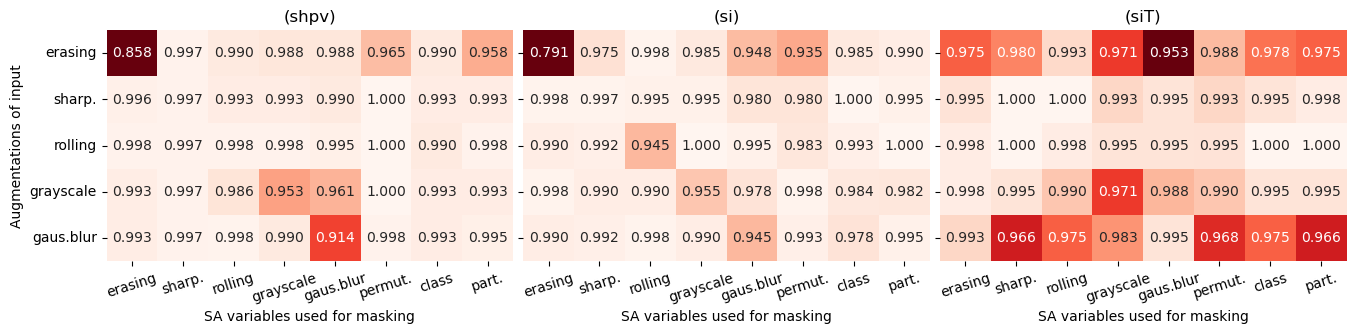

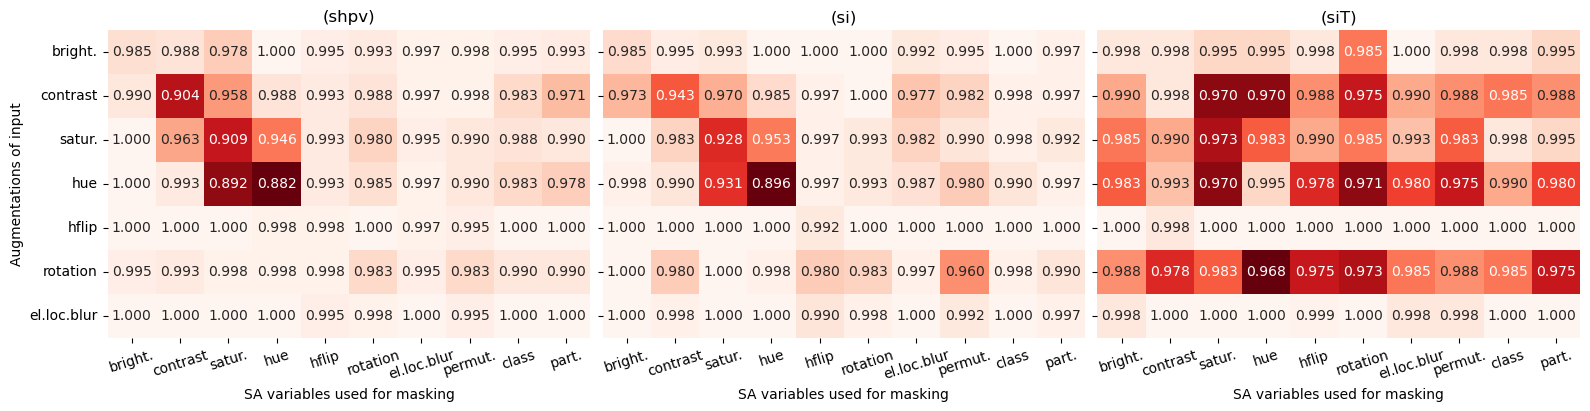

In [15]:
save_dirname = os.path.join(
    notebook_directory_offset,
    f'../results/{network_name}_{dataset_name}/masked_cor_patterns/'
)
os.makedirs(save_dirname, exist_ok=True)
save_filename_base = f'alexnet_masked_corpattern'

for i_aug, aug_set in enumerate(augmentation_set_numbers_list):
    prediction.crosscorr.plot_spearman_correlation_masked_activations_original_input_vs_augmented(
        featured_measurements_dict[aug_set],
        featured_measurements_no_aug_input_dict[aug_set],
        augmentation_set_number=aug_set,
        extract_auxilliary_names=True,
        figsize=figsizes_cormat[i_aug],
        show=True,
        cmap=cmap_cormat,
        save_path=os.path.join(save_dirname, f'{save_filename_base}_augset={aug_set}.pdf')
    )

### 1.3 Hierarchical cluster analysis for augmented inputs with masked activations

[[$\leftarrow$Prev.subsect.]](#1.2-Spearman-correlation-between-original-and-augmented-inputs-(both-masked))$\quad$[[Back to section]](#1.-Alexnet)$\quad$

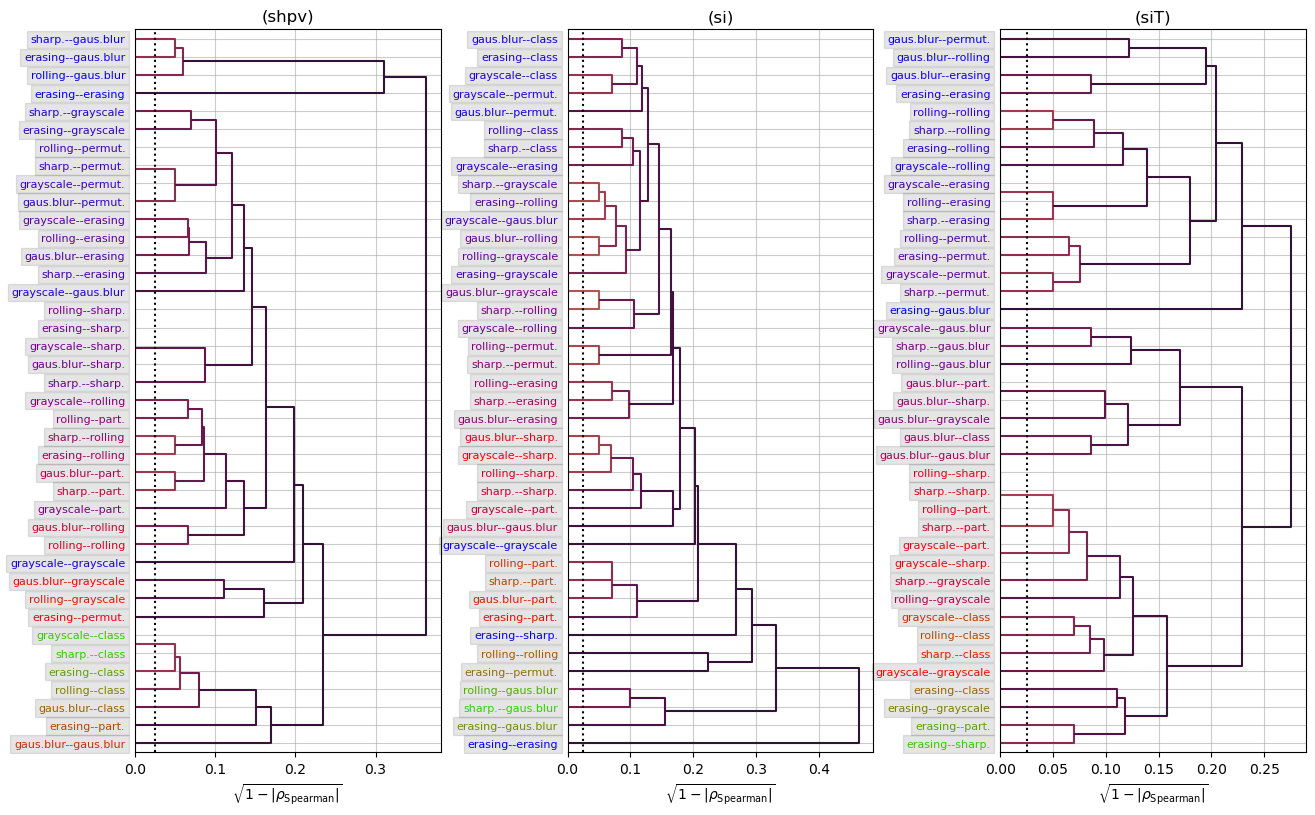

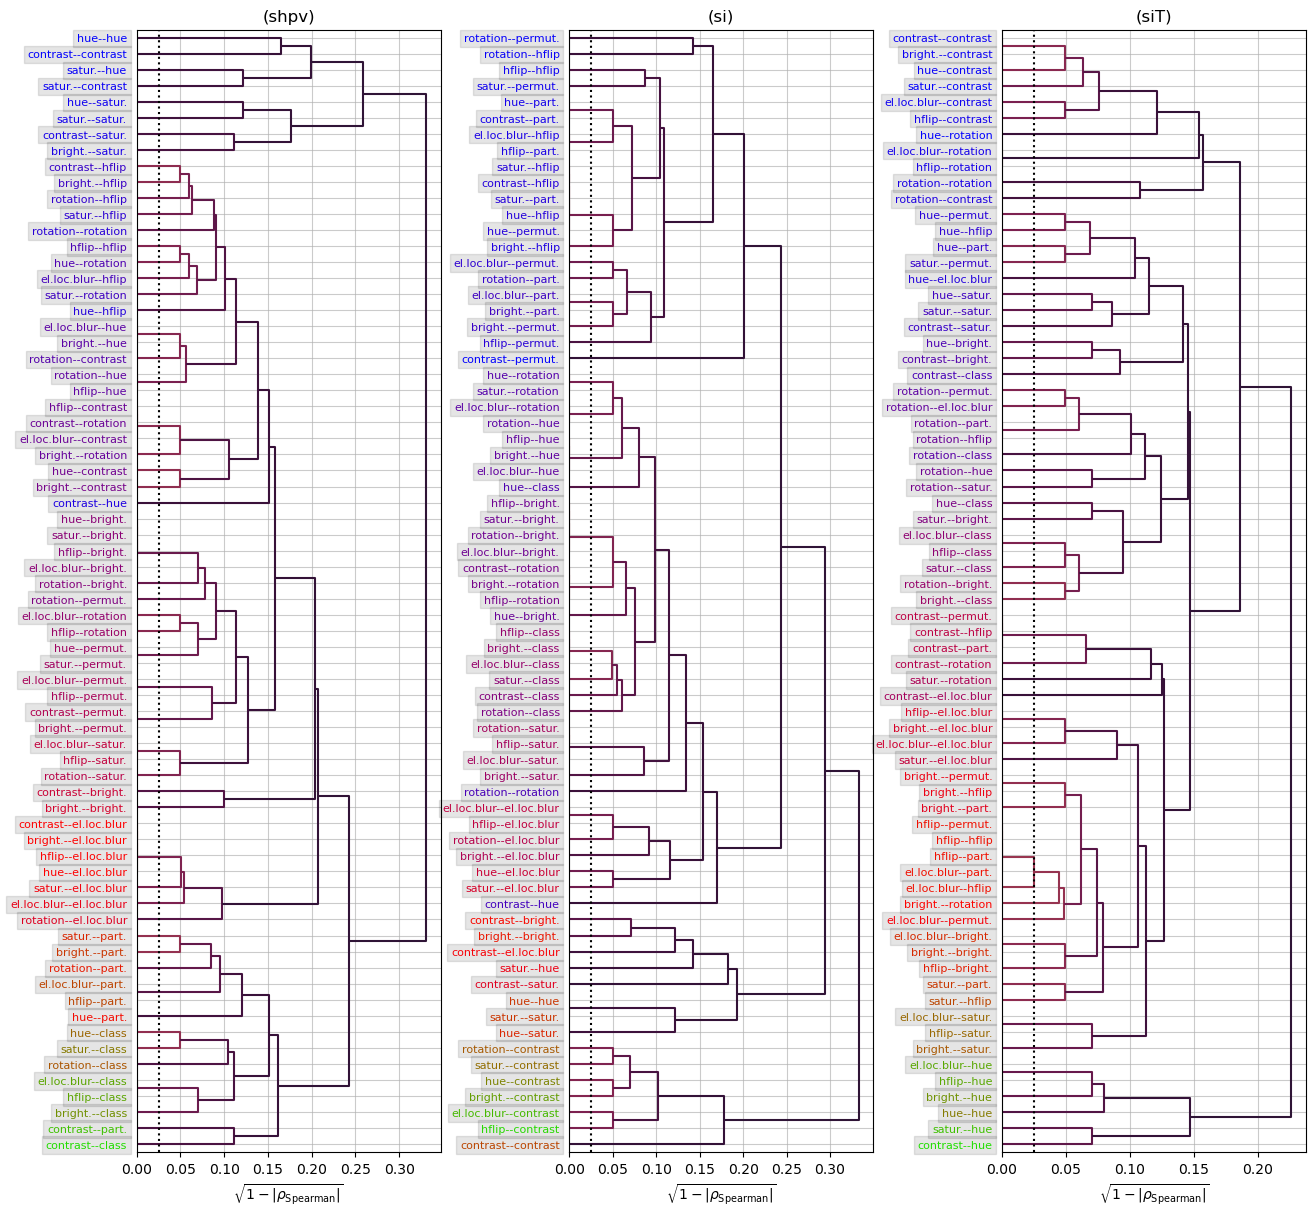

In [16]:
save_dirname = os.path.join(
    notebook_directory_offset,
    f'../results/{network_name}_{dataset_name}/masked_hca/'
)
os.makedirs(save_dirname, exist_ok=True)
save_filename_base = f'alexnet_masked_hca'

for i_aug, aug_set in enumerate(augmentation_set_numbers_list):
    prediction.hca.plot_hca_spearman_dendrogram(
        featured_measurements_dict[aug_set],
        augmentation_set_number=aug_set,
        extract_auxilliary_names=True,
        linkage=linkage_hca,
        figsize=figsizes_hca[i_aug],
        show=True,
        cmap=cmap_hca,
        label_cmap=label_cmap_hca,
        max_d_label=max_d_label_hca,
        label_background_color=label_background_color_hca,
        label_fontsize=label_fontsize_hca,
        save_path=os.path.join(save_dirname, f'{save_filename_base}_augset={aug_set}.pdf')
    )

## 2. ResNet18

[[$\leftarrow$ Prev.part]](#1.-Alexnet) $\qquad$ [[Back to top]](#Navigation) $\qquad$


- [2.1 Extract accuracy measurements](#2.1-Extract-accuracy-measurements)
- [2.2 Spearman correlation between original and augmented inputs (both masked)](#2.2-Spearman-correlation-between-original-and-augmented-inputs-(both-masked))
- [2.3 Hierarchical cluster analysis for augmented inputs with masked activations](#2.3-Hierarchical-cluster-analysis-for-augmented-inputs-with-masked-activations)

### 2.1 Extract accuracy measurements

$\quad$[[Back to section]](#2.-ResNet18)$\quad$[[Next subsect.$\to$]](#2.2-Spearman-correlation-between-original-and-augmented-inputs-(both-masked))

In [9]:
network_name = 'resnet18'

featured_measurements_dict = {}
featured_measurements_no_aug_input_dict = {}

for i_val, value_name in enumerate(sensitivity_value_name_list):
    print('='*80)
    print(value_name)
    print('='*80)
    results_path = os.path.join(
        notebook_directory_offset,
        results_dirname_path,
        f'{value_name}_{network_name}_{values_fnm_base}_pred_NOFCL_part={dataset_part}.hdf5'
    )
    results_top1, results_topn = prediction.compute.extract_accuracy(
        results_path,
        no_aug_key=no_aug_key,
        y_true_key=y_true_key,
        verbose=i_val == 0,
    )
    featured_measurements, featured_measurements_no_aug_input, measurements_no_mask_top_1 = (
        prediction.compute.collect_featured_measurements(
            results_top1,
            augmentation_set_numbers_list,
            alphas,
            percentiles,
            inverts,
            no_aug_key=no_aug_key,
        )
    )
    _, _, measurements_no_mask_top_n = (
        prediction.compute.collect_featured_measurements(
            results_topn,
            augmentation_set_numbers_list,
            alphas,
            percentiles,
            inverts,
            no_aug_key=no_aug_key,
        )
    )
    for aug_set_num in augmentation_set_numbers_list:
        print('Top-1 accuracy:')
        display(measurements_no_mask_top_1[aug_set_num])
        print('Top-5 accuracy:')
        display(measurements_no_mask_top_n[aug_set_num])
        
        featured_measurements_dict[aug_set_num] = featured_measurements_dict.get(aug_set_num, {})
        featured_measurements_no_aug_input_dict[aug_set_num] = featured_measurements_no_aug_input_dict.get(
            aug_set_num, {}
        )
        featured_measurements_dict[aug_set_num][value_name] = featured_measurements[aug_set_num]
        featured_measurements_no_aug_input_dict[aug_set_num][value_name] = (
            featured_measurements_no_aug_input[aug_set_num]
        )


shpv
Nsamples=36500: num.classes=365, min/mean/max samples per class=100/100.00/100
original::iaug=original top-1 acc=0.54
original::iaug=original top-5 acc=0.84
Top-1 accuracy:


,erasing,sharpness_const,rolling,grayscaling,gaussian_blur,original
0,0.441333,0.523534,0.4939,0.420904,0.478493,0.535014


Top-5 accuracy:


,erasing,sharpness_const,rolling,grayscaling,gaussian_blur,original
0,0.754648,0.827397,0.801489,0.729014,0.788977,0.836301


Top-1 accuracy:


...

,erasing,sharpness_const,rolling,grayscaling,gaussian_blur,original
0,0.75421,0.827397,0.801324,0.729014,0.789963,0.836301


Top-1 accuracy:


,brightness,contrast,saturation,hue,hflip,rotation,elliptic_local_blur,original
0,0.483105,0.458411,0.491461,0.418922,0.533014,0.477699,0.527315,0.535014


Top-5 accuracy:


,brightness,contrast,saturation,hue,hflip,rotation,elliptic_local_blur,original
0,0.786402,0.764831,0.800247,0.723644,0.834986,0.784539,0.831078,0.836301


### 3.2 Spearman correlation between original and augmented inputs (both masked)

[[$\leftarrow$Prev.subsect.]](#3.1-Extract-accuracy-measurements)$\quad$[[Back to section]](#3.-ResNet18)$\quad$[[Next subsect.$\to$]](#3.3-Hierarchical-cluster-analysis-for-augmented-inputs-with-masked-activations)

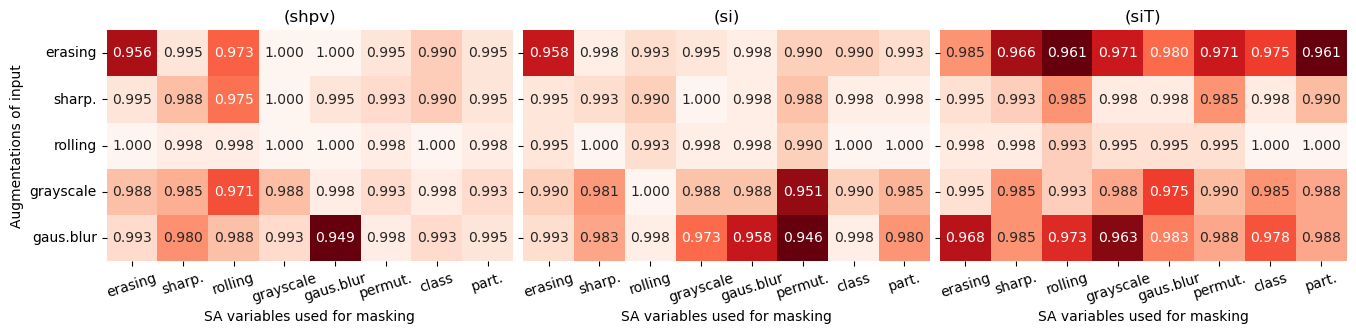

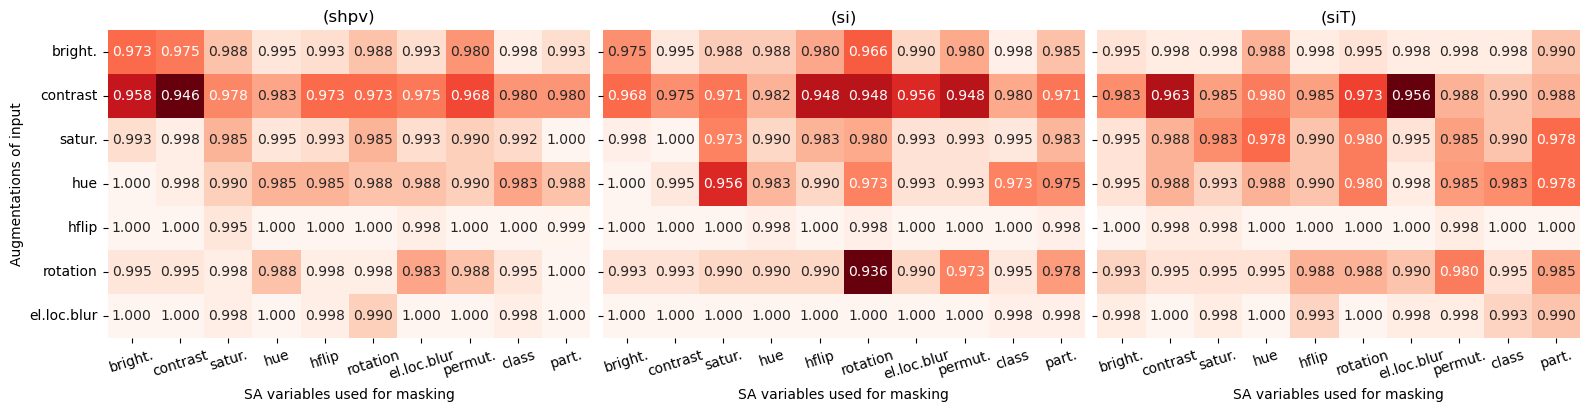

In [10]:
save_dirname = os.path.join(
    notebook_directory_offset,
    f'../results/{network_name}_{dataset_name}/masked_cor_patterns/'
)
os.makedirs(save_dirname, exist_ok=True)
save_filename_base = f'resnet18_masked_corpattern'

for i_aug, aug_set in enumerate(augmentation_set_numbers_list):
    prediction.crosscorr.plot_spearman_correlation_masked_activations_original_input_vs_augmented(
        featured_measurements_dict[aug_set],
        featured_measurements_no_aug_input_dict[aug_set],
        augmentation_set_number=aug_set,
        extract_auxilliary_names=True,
        figsize=figsizes_cormat[i_aug],
        show=True,
        cmap=cmap_cormat,
        save_path=os.path.join(save_dirname, f'{save_filename_base}_augset={aug_set}.pdf')
    );

### 3.3 Hierarchical cluster analysis for augmented inputs with masked activations

[[$\leftarrow$Prev.subsect.]](#3.2-Spearman-correlation-between-original-and-augmented-inputs-(both-masked))$\quad$[[Back to section]](#3.-ResNet18)$\quad$

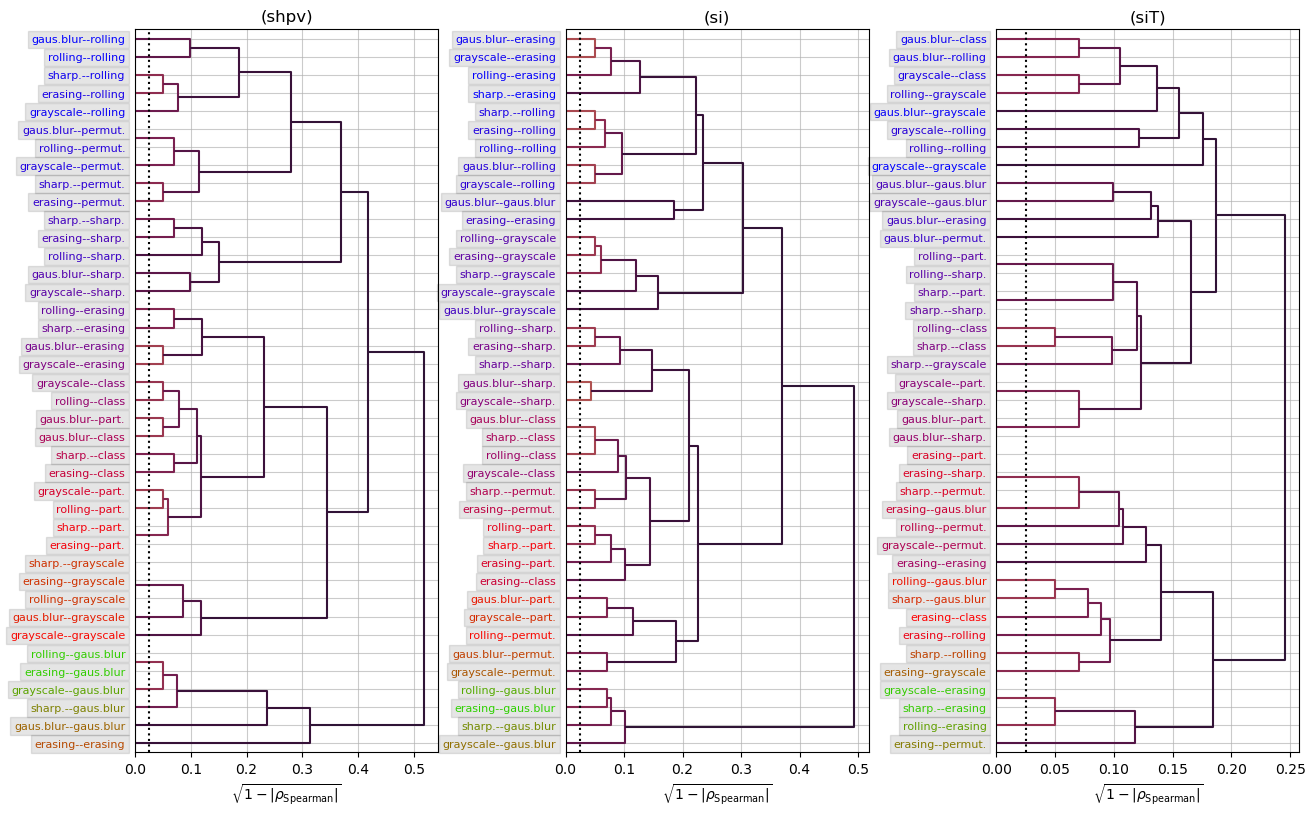

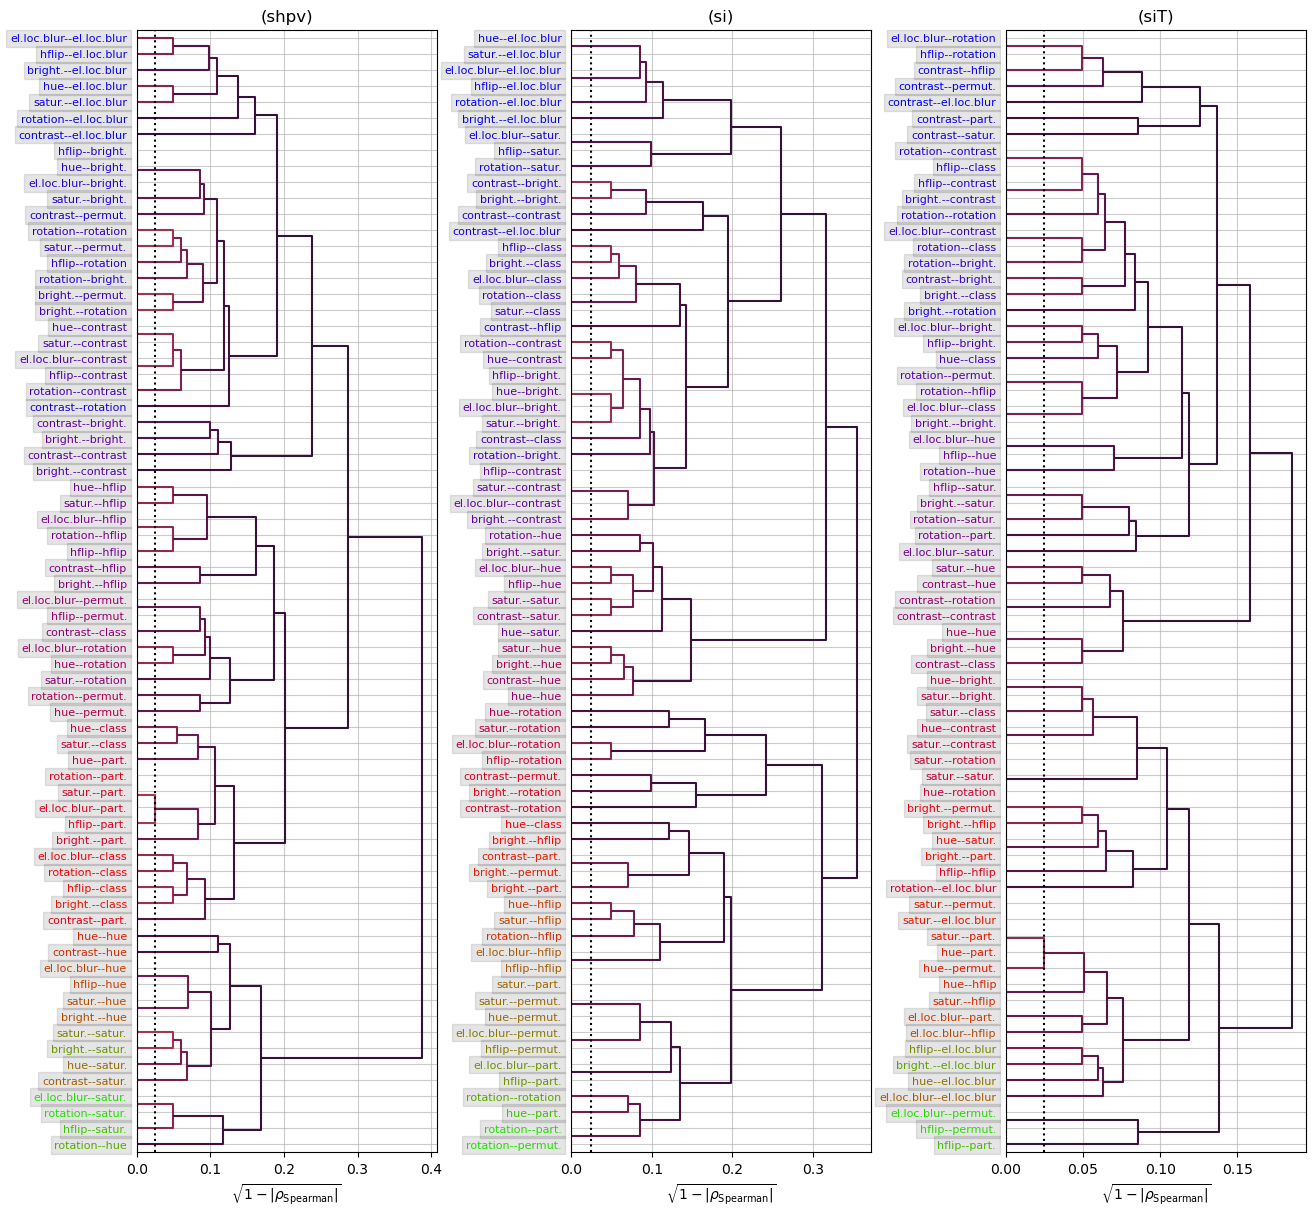

In [11]:
save_dirname = os.path.join(
    notebook_directory_offset,
    f'../results/{network_name}_{dataset_name}/masked_hca/'
)
os.makedirs(save_dirname, exist_ok=True)
save_filename_base = f'resnet18_masked_hca'

for i_aug, aug_set in enumerate(augmentation_set_numbers_list):
    prediction.hca.plot_hca_spearman_dendrogram(
        featured_measurements_dict[aug_set],
        augmentation_set_number=aug_set,
        extract_auxilliary_names=True,
        linkage=linkage_hca,
        figsize=figsizes_hca[i_aug],
        show=True,
        cmap=cmap_hca,
        label_cmap=label_cmap_hca,
        max_d_label=max_d_label_hca,
        label_background_color=label_background_color_hca,
        label_fontsize=label_fontsize_hca,
        save_path=os.path.join(save_dirname, f'{save_filename_base}_augset={aug_set}.pdf')
    )